In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
# Load the retail sales dataset
df = pd.read_csv("Retail_Sales.csv")

# Display first 5 rows
df.head()

,transactions_id,sale_date,sale_time,customer_id,gender,age,category,quantiy,price_per_unit,cogs,total_sale
0,180,2022-11-05,10:47:00,117,Male,41.0,Clothing,3.0,300.0,129.0,900.0
1,522,2022-07-09,11:00:00,52,Male,46.0,Beauty,3.0,500.0,145.0,1500.0
2,559,2022-12-12,10:48:00,5,Female,40.0,Clothing,4.0,300.0,84.0,1200.0
3,1180,2022-01-06,08:53:00,85,Male,41.0,Clothing,3.0,300.0,129.0,900.0
4,1522,2022-11-14,08:35:00,48,Male,46.0,Beauty,3.0,500.0,235.0,1500.0


In [3]:
# Check dataset dimensions
print("Dataset Shape:", df.shape)

# Check column names
print("\nColumn Names:")
print(df.columns.tolist())

# Check data types and missing values
print("\nDataset Information:")
df.info()

Dataset Shape: (2000, 11)

Column Names:
['transactions_id', 'sale_date', 'sale_time', 'customer_id', 'gender', 'age', 'category', 'quantiy', 'price_per_unit', 'cogs', 'total_sale']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   transactions_id  2000 non-null   int64  
 1   sale_date        2000 non-null   str    
 2   sale_time        2000 non-null   str    
 3   customer_id      2000 non-null   int64  
 4   gender           2000 non-null   str    
 5   age              1990 non-null   float64
 6   category         2000 non-null   str    
 7   quantiy          1997 non-null   float64
 8   price_per_unit   1997 non-null   float64
 9   cogs             1997 non-null   float64
 10  total_sale       1997 non-null   float64
dtypes: float64(5), int64(2), str(4)
memory usage: 172.0 KB


In [4]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
transactions_id     0
sale_date           0
sale_time           0
customer_id         0
gender              0
age                10
category            0
quantiy             3
price_per_unit      3
cogs                3
total_sale          3
dtype: int64

Duplicate Rows: 0


In [5]:
# Handle missing values

# Fill missing age with median age
df['age'] = df['age'].fillna(df['age'].median())

# Fill missing numerical sales columns with their median
for col in ['quantiy', 'price_per_unit', 'cogs', 'total_sale']:
    df[col] = df[col].fillna(df[col].median())

# Check missing values again
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
transactions_id    0
sale_date          0
sale_time          0
customer_id        0
gender             0
age                0
category           0
quantiy            0
price_per_unit     0
cogs               0
total_sale         0
dtype: int64


In [6]:
# Check and remove duplicate records

print("Duplicate rows before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate rows after:", df.duplicated().sum())
print("Dataset shape after cleaning:", df.shape)

Duplicate rows before: 0
Duplicate rows after: 0
Dataset shape after cleaning: (2000, 11)


In [7]:
# Convert sale_date into datetime format

df['sale_date'] = pd.to_datetime(df['sale_date'], errors='coerce')

print("Date conversion completed.")
print(df['sale_date'].dtype)
print(df['sale_date'].min())
print(df['sale_date'].max())

Date conversion completed.
datetime64[us]
2022-01-01 00:00:00
2023-12-31 00:00:00


In [8]:
# Create RFM table

reference_date = df['sale_date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    Recency=('sale_date', lambda x: (reference_date - x.max()).days),
    Frequency=('transactions_id', 'count'),
    Monetary=('total_sale', 'sum')
).reset_index()

print("RFM table created successfully!")
print("Number of customers:", len(rfm))

rfm.head(10)

RFM table created successfully!
Number of customers: 155


,customer_id,Recency,Frequency,Monetary
0,1,21,76,30750.0
1,2,25,69,25295.0
2,3,1,76,38440.0
3,4,2,73,23580.0
4,5,2,63,30405.0
5,6,107,7,1625.0
6,7,41,7,1695.0
7,8,32,6,2330.0
8,9,64,6,2880.0
9,10,88,6,2450.0


In [9]:
# Descriptive statistics of RFM variables

print("RFM Statistics:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

print("\nRFM Shape:", rfm.shape)

rfm.head()

RFM Statistics:
          Recency   Frequency      Monetary
count  155.000000  155.000000    155.000000
mean    75.741935   12.903226   5884.967742
std    110.238221   11.802363   5344.993424
min      1.000000    2.000000    200.000000
25%     13.000000    7.000000   2737.500000
50%     35.000000   10.000000   4650.000000
75%     83.000000   15.000000   7412.500000
max    687.000000   76.000000  38440.000000

RFM Shape: (155, 4)


,customer_id,Recency,Frequency,Monetary
0,1,21,76,30750.0
1,2,25,69,25295.0
2,3,1,76,38440.0
3,4,2,73,23580.0
4,5,2,63,30405.0


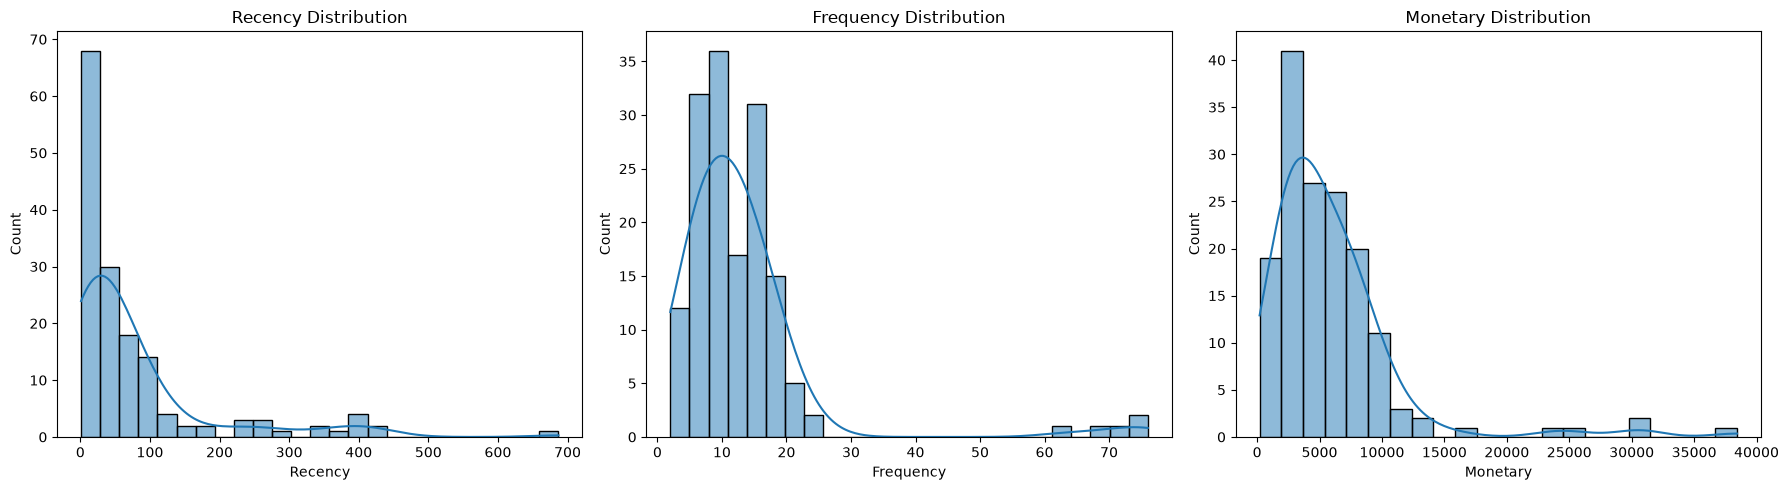

In [10]:
# Visualize RFM distributions

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['Recency'], kde=True, ax=axes[0])
axes[0].set_title('Recency Distribution')

sns.histplot(rfm['Frequency'], kde=True, ax=axes[1])
axes[1].set_title('Frequency Distribution')

sns.histplot(rfm['Monetary'], kde=True, ax=axes[2])
axes[2].set_title('Monetary Distribution')

plt.tight_layout()
plt.show()

In [11]:
# Standardize RFM variables

rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

print("RFM data standardized successfully.")
print("Scaled data shape:", rfm_scaled.shape)

RFM data standardized successfully.
Scaled data shape: (155, 3)


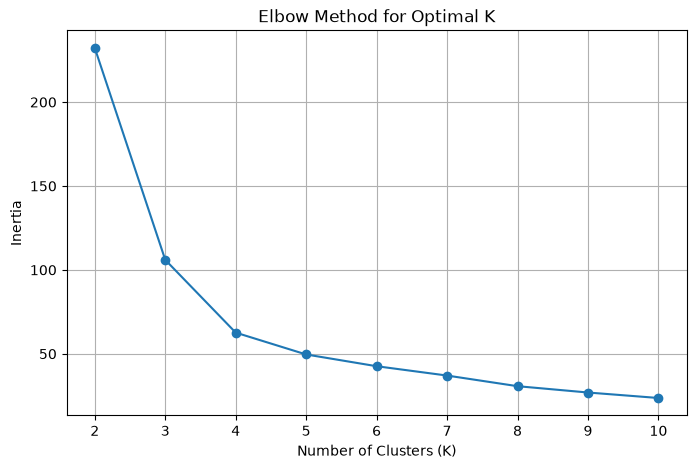

In [12]:
# Elbow Method to determine the optimal number of clusters

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [13]:
# Apply K-Means clustering with 4 clusters

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("K-Means clustering completed successfully!")
print("\nCluster counts:")
print(rfm['Cluster'].value_counts().sort_index())

K-Means clustering completed successfully!

Cluster counts:
Cluster
0    56
1    17
2     5
3    77
Name: count, dtype: int64


In [14]:
# Profile each customer segment

cluster_profile = rfm.groupby('Cluster').agg(
    Customers=('customer_id', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(2)

cluster_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,56,24.38,15.79,8266.88
1,17,352.00,6.00,2790.88
2,5,10.20,71.40,29694.00
3,77,56.36,8.53,3289.74


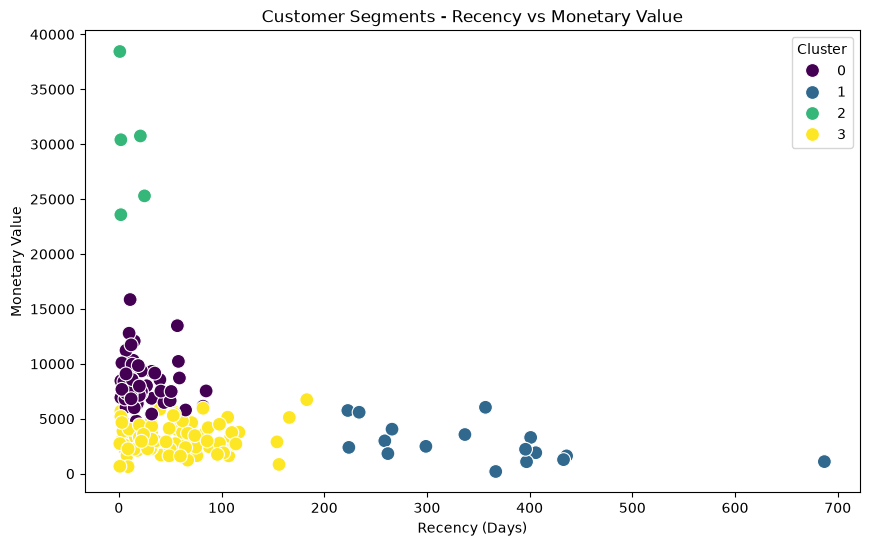

In [15]:
# Visualize customer clusters

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=100
)

plt.title('Customer Segments - Recency vs Monetary Value')
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary Value')
plt.legend(title='Cluster')
plt.show()

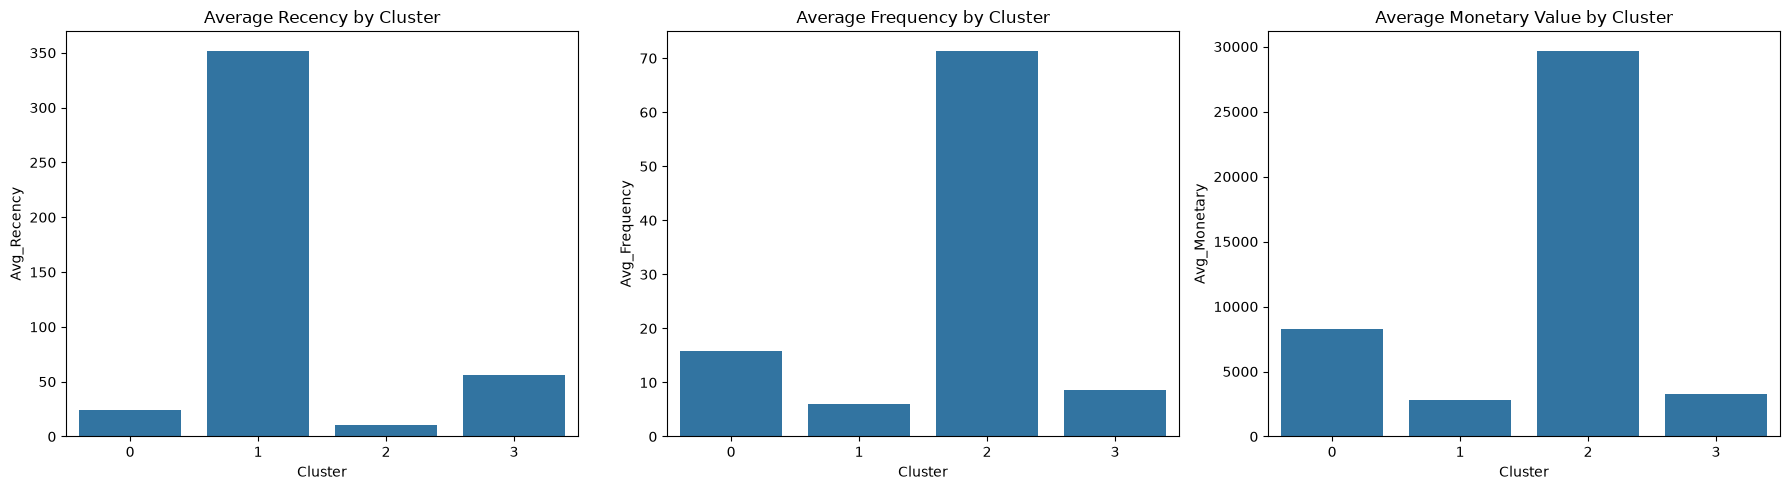

In [16]:
# Compare RFM metrics across clusters

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=cluster_profile.reset_index(),
            x='Cluster', y='Avg_Recency', ax=axes[0])
axes[0].set_title('Average Recency by Cluster')

sns.barplot(data=cluster_profile.reset_index(),
            x='Cluster', y='Avg_Frequency', ax=axes[1])
axes[1].set_title('Average Frequency by Cluster')

sns.barplot(data=cluster_profile.reset_index(),
            x='Cluster', y='Avg_Monetary', ax=axes[2])
axes[2].set_title('Average Monetary Value by Cluster')

plt.tight_layout()
plt.show()

In [17]:
# Assign meaningful business names to the clusters

cluster_names = {
    0: 'Potential Loyal Customers',
    1: 'At Risk Customers',
    2: 'High Value Loyal Customers',
    3: 'New / Low Value Customers'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_names)

print("Customer Segment Distribution:")
print(rfm['Segment'].value_counts())

print("\nCluster-wise Segment Profile:")
print(
    rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']]
       .mean()
       .round(2)
)

Customer Segment Distribution:
Segment
New / Low Value Customers     77
Potential Loyal Customers     56
At Risk Customers             17
High Value Loyal Customers     5
Name: count, dtype: int64

Cluster-wise Segment Profile:
                            Recency  Frequency  Monetary
Segment                                                 
At Risk Customers            352.00       6.00   2790.88
High Value Loyal Customers    10.20      71.40  29694.00
New / Low Value Customers     56.36       8.53   3289.74
Potential Loyal Customers     24.38      15.79   8266.88


In [18]:
# Final business recommendations

print("CUSTOMER SEGMENTATION INSIGHTS")
print("=" * 40)

print("\n1. High Value Loyal Customers:")
print("These customers have high purchase frequency and high monetary value.")
print("Recommendation: Reward them with loyalty benefits, exclusive offers, and premium services.")

print("\n2. Potential Loyal Customers:")
print("These customers show good purchasing activity and can be converted into loyal customers.")
print("Recommendation: Use personalized offers, loyalty programs, and targeted promotions.")

print("\n3. At Risk Customers:")
print("These customers have not purchased recently.")
print("Recommendation: Send reactivation campaigns, discounts, and personalized reminders.")

print("\n4. New / Low Value Customers:")
print("These customers have relatively low purchase frequency and monetary value.")
print("Recommendation: Use introductory offers, product recommendations, and engagement campaigns.")

print("\nOverall Recommendation:")
print("Customer segmentation can help the business personalize marketing strategies,")
print("improve customer retention, and focus resources on high-value customer groups.")

CUSTOMER SEGMENTATION INSIGHTS

1. High Value Loyal Customers:
These customers have high purchase frequency and high monetary value.
Recommendation: Reward them with loyalty benefits, exclusive offers, and premium services.

2. Potential Loyal Customers:
These customers show good purchasing activity and can be converted into loyal customers.
Recommendation: Use personalized offers, loyalty programs, and targeted promotions.

3. At Risk Customers:
These customers have not purchased recently.
Recommendation: Send reactivation campaigns, discounts, and personalized reminders.

4. New / Low Value Customers:
These customers have relatively low purchase frequency and monetary value.
Recommendation: Use introductory offers, product recommendations, and engagement campaigns.

Overall Recommendation:
Customer segmentation can help the business personalize marketing strategies,
improve customer retention, and focus resources on high-value customer groups.


In [19]:
# Save the final customer segmentation dataset

rfm.to_csv("Customer_Segmentation_Final.csv", index=False)

print("Customer segmentation dataset saved successfully!")
print("File: Customer_Segmentation_Final.csv")

print("\nFinal Dataset Shape:", rfm.shape)
print("\nFinal Columns:")
print(rfm.columns.tolist())

Customer segmentation dataset saved successfully!
File: Customer_Segmentation_Final.csv

Final Dataset Shape: (155, 6)

Final Columns:
['customer_id', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']
